# Portfolio Risk Engine
**MSc FBD — Portfolio Risk Management with Python (NEOMA) — Projet final**

Moteur de risque interactif construit sur des données Yahoo Finance : rendements, volatilité, Sharpe, drawdown, corrélations, VaR et Expected Shortfall (historique, paramétrique, Monte Carlo), contribution au risque, backtesting (Kupiec, feu tricolore de Bâle) et module de stress tests (historique, hypothétique, corrélation, volatilité, reverse).

**Mode d'emploi :** exécuter les cellules dans l'ordre (*Kernel → Restart & Run All*). Le moteur pose ses questions dans la section 1. **Appuyer sur Entrée** accepte la valeur par défaut (le portefeuille du projet). Pour tout exécuter sans questions, passer `INTERACTIVE = False`.

## 0. Imports et paramètres globaux

In [1]:
# !pip install yfinance scipy   # à décommenter si besoin

import os
import warnings
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm, chi2, skew, kurtosis
from scipy.special import xlogy

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

SEED = 42                                   # graine fixée → résultats reproductibles
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

INTERACTIVE = True                          # False = utiliser toutes les valeurs par défaut
TRADING_DAYS = 252
OUT_DIR = "resultats"                       # tableaux et graphiques pour le rapport
os.makedirs(OUT_DIR, exist_ok=True)

def eur(x):
    """Format monétaire lisible : 1234567.8 → '€1,234,568'."""
    return f"-€{-x:,.0f}" if x < 0 else f"€{x:,.0f}"

## 1. Inputs interactifs (avec validation)
Chaque question affiche une valeur par défaut entre crochets. En cas de saisie invalide, le moteur explique l'erreur et repose la question.

In [5]:
def ask(prompt, default, parse, check=None):
    """Pose une question, parse la réponse, la valide ; repose la question tant que c'est invalide."""
    while True:
        txt = input(f"{prompt} [défaut : {default}] : ").strip() if INTERACTIVE else ""
        if txt == "":
            txt = str(default)
        try:
            value = parse(txt)
        except Exception:
            print(f"   ✗ Format non reconnu : « {txt} ». Respecte le format de l'exemple entre crochets.")
            if not INTERACTIVE:
                raise
            continue
        msg = check(value) if check is not None else None
        if not msg:
            return value
        print(f"   ✗ Erreur : {msg} → Réessaie.")
        if not INTERACTIVE:
            raise ValueError(msg)

def parse_list(s, cast=float):
    return [cast(x) for x in s.replace(";", " ").split()]

def parse_tickers(s):
    return [t.strip().upper() for t in s.replace(";", ",").replace(" ", ",").split(",") if t.strip()]

def check_tickers(t):
    if len(t) < 2:
        return "il faut au moins 2 tickers."
    if len(set(t)) != len(t):
        return "un ticker apparaît deux fois."
    if len(t) < 6:
        print("   ⚠ Attention : l'énoncé demande au moins 6 tickers.")

DEFAULT_TICKERS = "SPY, AAPL, TLT, GLD, VNQ, MC.PA, TTE.PA"
TICKERS = ask("Tickers Yahoo Finance (séparés par des virgules)", DEFAULT_TICKERS, parse_tickers, check_tickers)
N = len(TICKERS)

DEFAULT_W = {"SPY": 20, "AAPL": 10, "TLT": 15, "GLD": 10, "VNQ": 10, "MC.PA": 20, "TTE.PA": 15}
default_w = " ".join(str(DEFAULT_W[t]) for t in TICKERS) if all(t in DEFAULT_W for t in TICKERS) \
    else " ".join([f"{100 / N:.4f}"] * N)

def check_weights(w):
    if len(w) != N:
        return f"{len(w)} poids saisis pour {N} tickers."
    if any(x < 0 for x in w):
        return "les poids doivent être positifs (portefeuille long-only)."
    if abs(sum(w) - 100) > 0.01:
        return f"les poids doivent sommer à 100 % (somme actuelle : {sum(w):.2f} %)."

WEIGHTS_PCT = ask(f"Poids en % dans l'ordre {TICKERS} (séparés par des espaces)",
                  default_w, lambda s: parse_list(s.replace(",", ".")), check_weights)
w = np.array(WEIGHTS_PCT) / 100

V = ask("Valeur du portefeuille en €", 1_000_000,
        lambda s: float(s.replace(" ", "").replace(",", ".")),
        lambda v: None if v > 0 else "la valeur doit être strictement positive.")

CONF = ask("Niveaux de confiance en % (séparés par des espaces)", "95 99",
           lambda s: [x / 100 for x in parse_list(s.replace(",", "."))],
           lambda c: None if c and all(0.5 < x < 1 for x in c) else "chaque niveau doit être entre 50 et 100 (exclus).")
CONF = sorted(CONF)
A_MAX = CONF[-1]                            # niveau le plus élevé (99 %) pour les ratios de stress

HORIZONS = ask("Horizons en jours (séparés par des espaces)", "1 10",
               lambda s: sorted(set(parse_list(s, int))),
               lambda h: None if h and all(1 <= x <= 250 for x in h) else "horizons entre 1 et 250 jours.")

START = ask("Date de début des données (AAAA-MM-JJ)", "2007-01-01",
            lambda s: pd.Timestamp(s).date().isoformat(),
            lambda d: None if pd.Timestamp(d) <= pd.Timestamp("2018-01-01")
            else "il faut au moins 5 ans incluant 2020 et 2022 : choisir une date ≤ 2018-01-01.")

EST_WINDOW = ask("Fenêtre d'estimation VaR en jours de bourse", 750, int,
                 lambda x: None if 100 <= x <= 5000 else "fenêtre entre 100 et 5000 jours.")

BT_WINDOW = ask("Fenêtre glissante du backtest en jours", 250, int,
                lambda x: None if 100 <= x <= 1000 else "fenêtre entre 100 et 1000 jours.")

N_SIMS = ask("Nombre de simulations Monte Carlo", 10_000, int,
             lambda x: None if 1_000 <= x <= 1_000_000 else "entre 1 000 et 1 000 000 simulations.")

RF = ask("Taux sans risque annuel en %", 3, lambda s: float(s.replace(",", ".")) / 100,
         lambda x: None if -0.05 <= x <= 0.2 else "taux entre -5 % et 20 %.")

print("\n✓ Paramètres retenus")
print(pd.DataFrame({"Poids": [f"{x:.1%}" for x in w], "Montant": [eur(x * V) for x in w]}, index=TICKERS))
print(f"Valeur {eur(V)} | confiance {[f'{c:.0%}' for c in CONF]} | horizons {HORIZONS} j | "
      f"fenêtre {EST_WINDOW} j | backtest {BT_WINDOW} j | {N_SIMS:,} simulations | rf {RF:.1%}")

Tickers Yahoo Finance (séparés par des virgules) [défaut : SPY, AAPL, TLT, GLD, VNQ, MC.PA, TTE.PA] : SPY, AAPL, TLT, GLD, VNQ, MC.PA, TTE.PA
Poids en % dans l'ordre ['SPY', 'AAPL', 'TLT', 'GLD', 'VNQ', 'MC.PA', 'TTE.PA'] (séparés par des espaces) [défaut : 20 10 15 10 10 20 15] : 20 10 15 10 10 20 15
Valeur du portefeuille en € [défaut : 1000000] : 1000000
Niveaux de confiance en % (séparés par des espaces) [défaut : 95 99] : 99
Horizons en jours (séparés par des espaces) [défaut : 1 10] : 1
Date de début des données (AAAA-MM-JJ) [défaut : 2007-01-01] : 2025-10-09
   ✗ Erreur : il faut au moins 5 ans incluant 2020 et 2022 : choisir une date ≤ 2018-01-01. → Réessaie.
Date de début des données (AAAA-MM-JJ) [défaut : 2007-01-01] : 2019-10-09
   ✗ Erreur : il faut au moins 5 ans incluant 2020 et 2022 : choisir une date ≤ 2018-01-01. → Réessaie.
Date de début des données (AAAA-MM-JJ) [défaut : 2007-01-01] : 2007-01-01
Fenêtre d'estimation VaR en jours de bourse [défaut : 750] : 750
Fenêtre

## 2. Données Yahoo Finance
### 2.1 Devise de chaque actif
Le portefeuille est valorisé en **euros**. La devise de cotation est lue sur Yahoo Finance ; si l'information n'est pas disponible, on la déduit du suffixe de place (`.PA`, `.DE`, `.AS`… → EUR, sinon USD).

In [6]:
EUR_SUFFIXES = (".PA", ".AS", ".DE", ".MI", ".MC", ".BR", ".LS", ".HE", ".VI", ".IR", ".F")

def get_currency(ticker):
    try:
        c = yf.Ticker(ticker).fast_info["currency"]
        if c:
            return c
    except Exception:
        pass
    return "EUR" if ticker.endswith(EUR_SUFFIXES) else "USD"

CCY = {t: get_currency(t) for t in TICKERS}
# Les actions de Londres cotent en pence (GBp) : on convertit en livres
PENCE = {t for t, c in CCY.items() if c in ("GBp", "GBX")}
CCY = {t: ("GBP" if t in PENCE else c.upper()) for t, c in CCY.items()}
FX_TICKERS = {c: f"EUR{c}=X" for c in set(CCY.values()) if c != "EUR"}   # EURUSD=X = dollars pour 1 €
print("Devises :", CCY)
print("Taux de change utilisés :", FX_TICKERS)

Devises : {'SPY': 'USD', 'AAPL': 'USD', 'TLT': 'USD', 'GLD': 'USD', 'VNQ': 'USD', 'MC.PA': 'EUR', 'TTE.PA': 'EUR'}
Taux de change utilisés : {'USD': 'EURUSD=X'}


### 2.2 Téléchargement des cours ajustés
`auto_adjust=True` → cours de clôture **ajustés** des dividendes et des splits (*adjusted close*).

In [7]:
END = date.today().isoformat()
raw = yf.download(TICKERS + list(FX_TICKERS.values()), start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
if isinstance(raw, pd.Series):
    raw = raw.to_frame()

missing = [t for t in TICKERS + list(FX_TICKERS.values()) if t not in raw.columns or raw[t].dropna().empty]
if missing:
    raise ValueError(f"Aucune donnée pour {missing} : vérifie l'orthographe des tickers sur finance.yahoo.com "
                     "puis relance la section 1.")

raw.index = pd.to_datetime(raw.index).tz_localize(None)
print("Dimensions brutes :", raw.shape)
print("\nPremière date disponible par série :")
print(raw.apply(lambda s: s.first_valid_index().date()))

Dimensions brutes : (5155, 8)

Première date disponible par série :
Ticker
AAPL        2007-01-03
EURUSD=X    2007-01-01
GLD         2007-01-03
MC.PA       2007-01-02
SPY         2007-01-03
TLT         2007-01-03
TTE.PA      2007-01-02
VNQ         2007-01-03
dtype: object


### 2.3 Alignement des calendriers, données manquantes et conversion en euros
- Les marchés n'ont pas les mêmes jours fériés (Thanksgiving à New York, 1er mai à Paris…). On supprime les jours où **aucun** actif n'a coté (Noël, 1er janvier) pour ne pas créer de faux rendements nuls.
- Un jour férié sur un seul marché → on reprend le dernier cours connu (*forward fill*), **limité à 5 jours** pour ne pas masquer un vrai trou.
- Conversion : **Prix € = Prix devise ÷ (EUR/devise)**. Le risque de change est donc inclus dans le risque du portefeuille, ce qui est cohérent pour un investisseur européen.
- `prices_eur` (sans aucune valeur manquante) sert aux mesures de risque ; `prices_full` (qui garde les actifs plus anciens même si un autre n'existe pas encore) sert à rejouer les crises historiques.

In [8]:
px = raw[raw[TICKERS].notna().any(axis=1)].copy()
n_closed = len(raw) - len(px)
n_nan_before = int(px.isna().sum().sum())
px = px.ffill(limit=5)

for t in PENCE:
    px[t] = px[t] / 100
prices_full = px[TICKERS].copy()
for t, c in CCY.items():
    if c != "EUR":
        prices_full[t] = px[t] / px[FX_TICKERS[c]]

prices_eur = prices_full.dropna()
n_nan_filled = n_nan_before - int(px.isna().sum().sum())

print(f"Jours fermés sur tous les marchés supprimés : {n_closed}")
print(f"Valeurs manquantes comblées par forward fill : {n_nan_filled}")
print(f"Période exploitable : {prices_eur.index[0].date()} → {prices_eur.index[-1].date()} "
      f"({len(prices_eur)} jours de bourse, {len(prices_eur) / TRADING_DAYS:.1f} ans)")
if prices_eur.index[0] > pd.Timestamp(START) + pd.Timedelta(days=30):
    late = prices_full.apply(lambda s: s.first_valid_index()).idxmax()
    print(f"⚠ L'historique commun commence tard à cause de {late} (première cotation).")

Jours fermés sur tous les marchés supprimés : 48
Valeurs manquantes comblées par forward fill : 785
Période exploitable : 2007-01-03 → 2026-10-08 (5100 jours de bourse, 20.2 ans)


### 2.4 Contrôles qualité

Année 2008 dans les données : OK
Année 2020 dans les données : OK
Année 2022 dans les données : OK

Variations journalières extrêmes (en %) — repérer d'éventuelles erreurs de données :
        Plus forte hausse        Date  Plus forte baisse       Date 
Ticker                                                              
SPY                  13.5  2008-12-09              -11.8  2008-12-08
AAPL                 15.8  2008-12-09              -16.7  2008-09-29
TLT                  17.7  2008-12-09              -14.9  2008-12-08
GLD                  15.6  2008-12-09              -12.8  2008-12-08
VNQ                  15.8  2009-03-23              -18.9  2008-12-01
MC.PA                12.9  2008-10-13              -11.2  2008-11-11
TTE.PA               15.1  2020-11-09              -16.6  2020-03-09


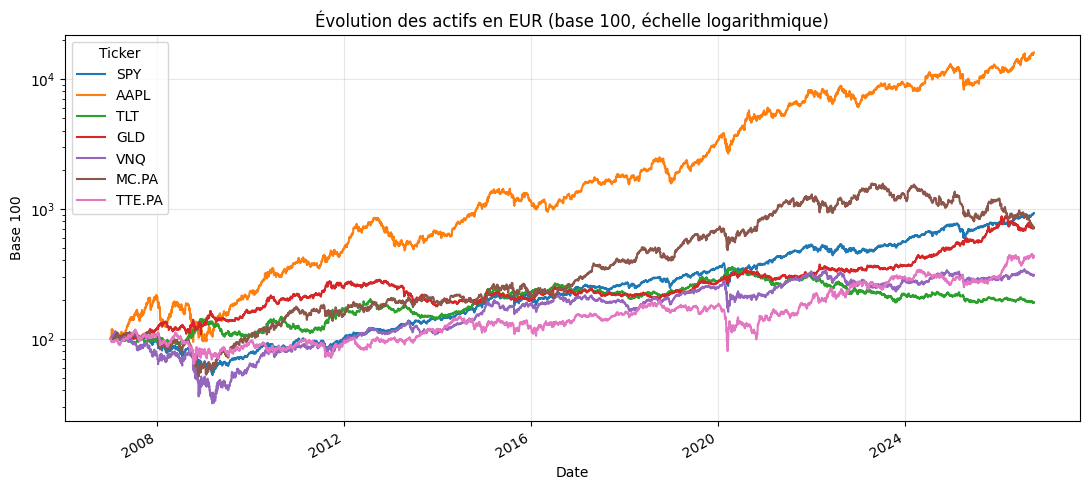

In [9]:
for y in [2008, 2020, 2022]:
    print(f"Année {y} dans les données : {'OK' if (prices_eur.index.year == y).any() else 'MANQUANTE'}")
assert len(prices_eur) >= 5 * TRADING_DAYS, "Moins de 5 ans d'historique commun : changer de tickers."

rets = prices_eur.pct_change().dropna()              # rendements simples (agrégeables entre actifs)
log_rets = np.log(prices_eur / prices_eur.shift(1)).dropna()

print("\nVariations journalières extrêmes (en %) — repérer d'éventuelles erreurs de données :")
print((pd.DataFrame({"Plus forte hausse": rets.max(), "Date": rets.idxmax().dt.date,
                     "Plus forte baisse": rets.min(), "Date ": rets.idxmin().dt.date})
       .assign(**{"Plus forte hausse": lambda d: (d["Plus forte hausse"] * 100).round(1),
                  "Plus forte baisse": lambda d: (d["Plus forte baisse"] * 100).round(1)})))

ax = (prices_eur / prices_eur.iloc[0] * 100).plot(figsize=(11, 5), logy=True)
ax.set_title("Évolution des actifs en EUR (base 100, échelle logarithmique)")
ax.set_ylabel("Base 100"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/01_prix_base100.png", dpi=150); plt.show()

### 2.5 Sauvegarde du dataset (CSV) et documentation de la source

In [11]:
prices_eur.to_csv("portfolio_prices_eur.csv", float_format="%.6f")
SOURCE_NOTE = (f"Source : Yahoo Finance (yfinance), cours de clôture ajustés. Téléchargement le {date.today()}. "
               f"Période : {prices_eur.index[0].date()} – {prices_eur.index[-1].date()} "
               f"({len(prices_eur)} jours de bourse). Devise : EUR (conversion via {', '.join(FX_TICKERS.values()) or 'aucune'}).")
with open("dataset_README.txt", "w", encoding="utf-8") as f:
    f.write(SOURCE_NOTE + f"\nTickers : {', '.join(TICKERS)}\nDevises d'origine : {CCY}\n"
            "Traitement : suppression des jours fermés partout, forward fill limité à 5 jours, conversion en EUR.\n")
print(SOURCE_NOTE)
print("✓ Fichiers enregistrés : portfolio_prices_eur.csv, dataset_README.txt")

Source : Yahoo Finance (yfinance), cours de clôture ajustés. Téléchargement le 2026-10-09. Période : 2007-01-03 – 2026-10-08 (5100 jours de bourse). Devise : EUR (conversion via EURUSD=X).
✓ Fichiers enregistrés : portfolio_prices_eur.csv, dataset_README.txt


## 3. Analytics : rendement, volatilité, Sharpe, drawdown, corrélations
- Rendement annualisé = moyenne des rendements log journaliers × 252
- Volatilité annualisée = écart-type journalier × √252
- Sharpe = (rendement − taux sans risque) ÷ volatilité
- Max drawdown = plus forte baisse depuis un plus haut

Le portefeuille est supposé **rebalancé quotidiennement** aux poids cibles : son rendement journalier est wᵀR.

In [10]:
port_rets = rets @ w
port_log = np.log1p(port_rets)

def max_drawdown(r):
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()

def perf_stats(simple, logr):
    ann_ret = logr.mean() * TRADING_DAYS
    ann_vol = simple.std() * np.sqrt(TRADING_DAYS)
    return pd.Series({"Rendement annuel": ann_ret, "Volatilité annuelle": ann_vol,
                      "Sharpe": (ann_ret - RF) / ann_vol, "Max drawdown": max_drawdown(simple),
                      "Skewness": skew(simple), "Excès de kurtosis": kurtosis(simple)})

stats = pd.DataFrame({t: perf_stats(rets[t], log_rets[t]) for t in TICKERS})
stats["PORTEFEUILLE"] = perf_stats(port_rets, port_log)
stats = stats.T
stats.to_csv(f"{OUT_DIR}/tab_performance.csv")

fmt = stats.copy()
for c in ["Rendement annuel", "Volatilité annuelle", "Max drawdown"]:
    fmt[c] = fmt[c].map("{:.1%}".format)
for c in ["Sharpe", "Skewness", "Excès de kurtosis"]:
    fmt[c] = fmt[c].map("{:.2f}".format)
print(f"Statistiques sur toute la période ({prices_eur.index[0].date()} – {prices_eur.index[-1].date()}), en EUR")
fmt

Statistiques sur toute la période (2007-01-03 – 2026-10-08), en EUR


,Rendement annuel,Volatilité annuelle,Sharpe,Max drawdown,Skewness,Excès de kurtosis
SPY,11.0%,21.0%,0.38,-51.2%,-0.15,12.91
AAPL,25.1%,32.2%,0.68,-56.5%,0.01,6.25
TLT,3.2%,18.8%,0.01,-47.3%,0.50,19.46
GLD,9.7%,20.0%,0.34,-37.6%,0.14,11.65
VNQ,5.6%,29.6%,0.09,-72.2%,-0.13,14.22
MC.PA,9.7%,29.0%,0.23,-54.8%,0.35,5.13
TTE.PA,7.3%,26.8%,0.16,-58.7%,0.07,10.74
PORTEFEUILLE,11.8%,15.1%,0.58,-29.6%,-0.04,10.76


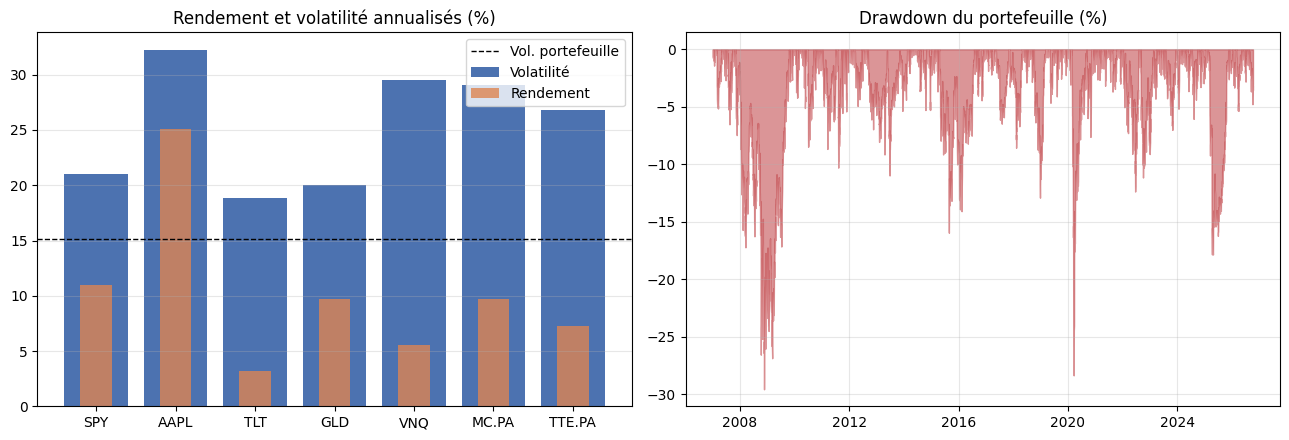

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
s = stats.drop("PORTEFEUILLE")
axes[0].bar(s.index, s["Volatilité annuelle"] * 100, color="#4C72B0", label="Volatilité")
axes[0].bar(s.index, s["Rendement annuel"] * 100, color="#DD8452", alpha=0.8, width=0.4, label="Rendement")
axes[0].axhline(stats.loc["PORTEFEUILLE", "Volatilité annuelle"] * 100, ls="--", c="k", lw=1, label="Vol. portefeuille")
axes[0].set_title("Rendement et volatilité annualisés (%)"); axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

dd = (1 + port_rets).cumprod()
axes[1].fill_between(dd.index, (dd / dd.cummax() - 1) * 100, color="#C44E52", alpha=0.6)
axes[1].set_title("Drawdown du portefeuille (%)"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/02_rendement_vol_drawdown.png", dpi=150); plt.show()

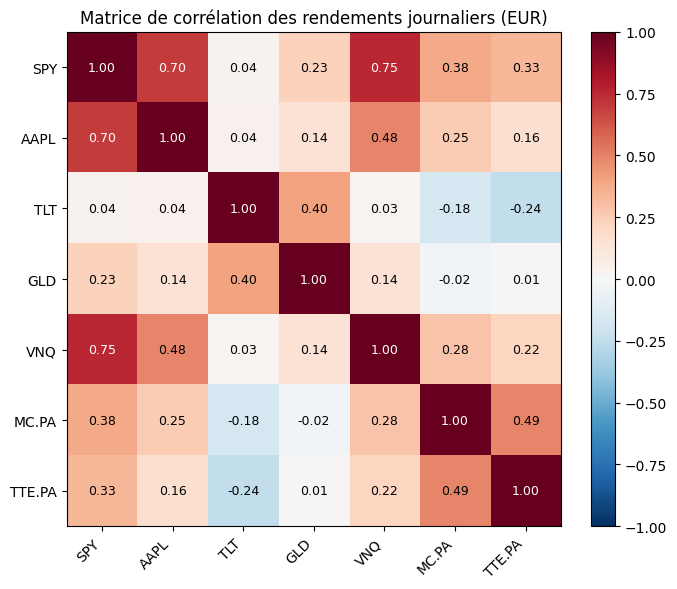

In [13]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(N)); ax.set_xticklabels(TICKERS, rotation=45, ha="right")
ax.set_yticks(range(N)); ax.set_yticklabels(TICKERS)
for i in range(N):
    for j in range(N):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black", fontsize=9)
fig.colorbar(im, fraction=0.046)
ax.set_title("Matrice de corrélation des rendements journaliers (EUR)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/03_heatmap_correlation.png", dpi=150); plt.show()

## 4. Value at Risk et Expected Shortfall
Estimation sur les **`EST_WINDOW` derniers jours** (par défaut 750 ≈ 3 ans), pondérations actuelles.

| Méthode | Principe | Horizon h jours |
|---|---|---|
| Historique | quantile empirique des P&L passés ; ES = moyenne des pertes au-delà | rendements **chevauchants** sur h jours |
| Paramétrique (normale) | VaR = (z·σ − μ)·V ; ES = (σ·φ(z)/(1−α) − μ)·V | μ×h, σ×√h |
| Monte Carlo | N tirages d'une normale multivariée N(μ, Σ) (factorisation de Σ) | μ×h, Σ×h |

VaR et ES sont exprimées en **pertes positives en euros**.

In [14]:
est = rets.iloc[-EST_WINDOW:]
EST_PERIOD = f"{est.index[0].date()} – {est.index[-1].date()}"
mu_vec = est.mean().values
cov = est.cov().values
mu_p = w @ mu_vec
sig_p = np.sqrt(w @ cov @ w)

def var_es_empirical(pnl, a):
    """VaR et ES à partir d'un vecteur de P&L (en €)."""
    pnl = np.asarray(pnl)
    q = np.quantile(pnl, 1 - a)
    return -q, -pnl[pnl <= q].mean()

def var_es_normal(mu, sigma, a, value):
    z = norm.ppf(a)
    return (z * sigma - mu) * value, (sigma * norm.pdf(z) / (1 - a) - mu) * value

def matrix_root(C):
    """Racine A telle que A·Aᵀ = C (via valeurs propres : fonctionne même si C est singulière, ex. ρ = 1)."""
    vals, vecs = np.linalg.eigh(C)
    return vecs * np.sqrt(np.clip(vals, 0, None))

def simulate_pnl(mu, C, h, n=N_SIMS, seed=SEED, weights=None):
    weights = w if weights is None else weights
    g = np.random.default_rng(seed)
    Z = g.standard_normal((n, len(mu)))
    R = mu * h + Z @ matrix_root(C * h).T
    return V * (R @ weights)

results = {}
mc_pnl = {}
for h in HORIZONS:
    if h == 1:
        hist_pnl = V * (est @ w).values
    else:
        hist_pnl = V * (np.exp(np.log1p(est @ w).rolling(h).sum()) - 1).dropna().values
    mc_pnl[h] = simulate_pnl(mu_vec, cov, h)
    for a in CONF:
        results[(h, "Historique", a)] = var_es_empirical(hist_pnl, a)
        results[(h, "Paramétrique", a)] = var_es_normal(mu_p * h, sig_p * np.sqrt(h), a, V)
        results[(h, "Monte Carlo", a)] = var_es_empirical(mc_pnl[h], a)

def results_table(h):
    rows = {}
    for m in ["Historique", "Paramétrique", "Monte Carlo"]:
        r = {}
        for a in CONF:
            r[f"VaR {a:.0%}"] = results[(h, m, a)][0]
        for a in CONF:
            r[f"ES {a:.0%}"] = results[(h, m, a)][1]
        rows[m] = r
    return pd.DataFrame(rows).T

for h in HORIZONS:
    tab = results_table(h)
    tab.to_csv(f"{OUT_DIR}/tab_var_es_{h}j.csv")
    print(f"\n=== VaR et ES — horizon {h} jour(s) — portefeuille {eur(V)} ===")
    print(tab.map(eur).to_string())
print(f"\nSource : Yahoo Finance (cours ajustés, convertis en EUR). Fenêtre d'estimation : {EST_PERIOD} "
      f"({EST_WINDOW} jours). Monte Carlo : {N_SIMS:,} simulations, graine {SEED}.")


=== VaR et ES — horizon 1 jour(s) — portefeuille €1,000,000 ===
              VaR 99%   ES 99%
Historique    €19,725  €28,666
Paramétrique  €16,954  €19,478
Monte Carlo   €17,370  €20,125

Source : Yahoo Finance (cours ajustés, convertis en EUR). Fenêtre d'estimation : 2023-11-13 – 2026-10-08 (750 jours). Monte Carlo : 10,000 simulations, graine 42.


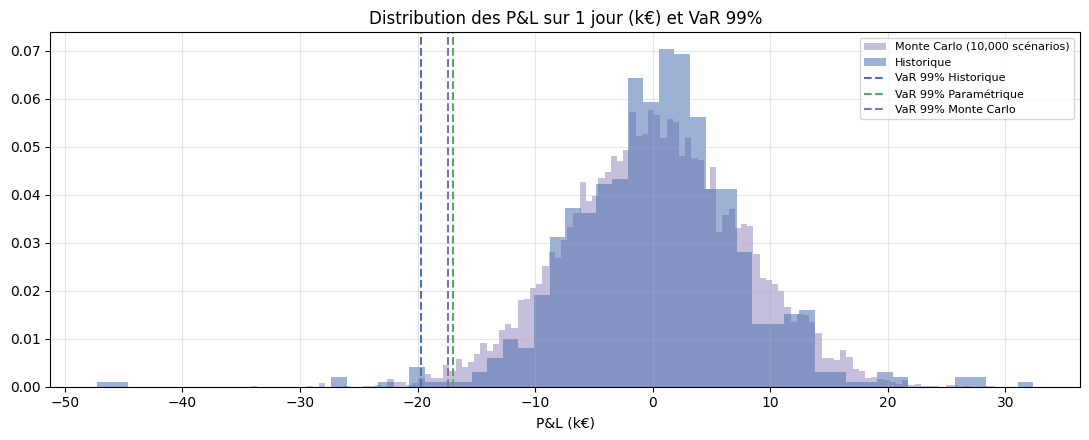

In [15]:
h0 = HORIZONS[0]
hist_pnl_1d = V * (est @ w).values
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(mc_pnl[h0] / 1e3, bins=120, density=True, alpha=0.45, color="#8172B3", label=f"Monte Carlo ({N_SIMS:,} scénarios)")
ax.hist(hist_pnl_1d / 1e3, bins=60, density=True, alpha=0.55, color="#4C72B0", label="Historique")
for m, c in [("Historique", "#4C72B0"), ("Paramétrique", "#55A868"), ("Monte Carlo", "#8172B3")]:
    ax.axvline(-results[(h0, m, A_MAX)][0] / 1e3, color=c, ls="--", lw=1.5, label=f"VaR {A_MAX:.0%} {m}")
ax.set_title(f"Distribution des P&L sur {h0} jour (k€) et VaR {A_MAX:.0%}")
ax.set_xlabel("P&L (k€)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/04_distribution_pnl_var.png", dpi=150); plt.show()

### 4.1 Convergence du Monte Carlo
L'erreur d'estimation de la VaR Monte Carlo diminue en 1/√N : on le vérifie sur 25 répétitions.

In [16]:
conv = []
for n in [1_000, 10_000, 100_000]:
    v = [var_es_empirical(simulate_pnl(mu_vec, cov, 1, n=n, seed=SEED + k), A_MAX)[0] for k in range(25)]
    conv.append({"Simulations": f"{n:,}", f"VaR {A_MAX:.0%} moyenne": eur(np.mean(v)), "Écart-type": eur(np.std(v, ddof=1))})
pd.DataFrame(conv).set_index("Simulations")

,VaR 99% moyenne,Écart-type
Simulations,,
"1,000","€16,834",€810
"10,000","€16,880",€291
"100,000","€16,928",€84


### 4.2 Contribution au risque par actif
- **Paramétrique (Euler)** : contribution de l'actif i = wᵢ·(Σw)ᵢ / σₚ ; les contributions somment exactement à la volatilité (et donc à la VaR paramétrique).
- **Historique (ES)** : perte moyenne de chaque actif pendant les jours de la queue de distribution (les pires (1−α) % des jours).

         Poids Volatilité annuelle Part du risque (Euler) Contribution VaR 99% param. Contribution ES 99% hist.
SPY      20.0%               16.4%                  19.6%                      €3,321                    €6,326
AAPL     10.0%               27.6%                  14.2%                      €2,401                    €4,271
TLT      15.0%               14.0%                   7.8%                      €1,327                    €2,225
GLD      10.0%               22.5%                   7.8%                      €1,329                    €1,548
VNQ      10.0%               17.3%                   9.3%                      €1,580                    €3,516
MC.PA    20.0%               29.7%                  32.0%                      €5,430                    €6,670
TTE.PA   15.0%               21.1%                   9.2%                      €1,565                    €4,111
TOTAL   100.0%               11.8%                 100.0%                     €16,954                   

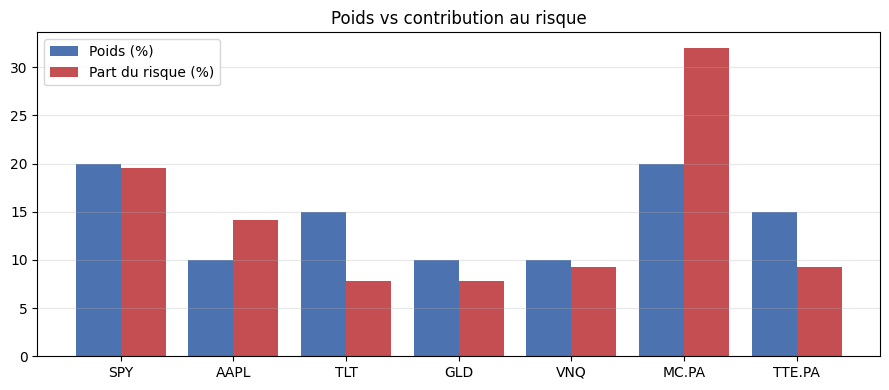

In [17]:
marg = cov @ w / sig_p
comp = w * marg
share = comp / sig_p
var_param_max = results[(1, "Paramétrique", A_MAX)][0] if 1 in HORIZONS else var_es_normal(mu_p, sig_p, A_MAX, V)[0]

port_est = est @ w
tail_days = port_est <= np.quantile(port_est, 1 - A_MAX)
es_contrib = -(est[tail_days] * w).mean() * V

contrib = pd.DataFrame({
    "Poids": w,
    "Volatilité annuelle": est.std().values * np.sqrt(TRADING_DAYS),
    "Part du risque (Euler)": share,
    f"Contribution VaR {A_MAX:.0%} param.": share * var_param_max,
    f"Contribution ES {A_MAX:.0%} hist.": es_contrib.values,
}, index=TICKERS)
contrib.loc["TOTAL"] = contrib.sum()
contrib.loc["TOTAL", "Volatilité annuelle"] = sig_p * np.sqrt(TRADING_DAYS)
contrib.to_csv(f"{OUT_DIR}/tab_contribution_risque.csv")

show = contrib.copy()
for c in ["Poids", "Volatilité annuelle", "Part du risque (Euler)"]:
    show[c] = show[c].map("{:.1%}".format)
for c in show.columns[3:]:
    show[c] = contrib[c].map(eur)
print(show.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(N)
ax.bar(x - 0.2, w * 100, 0.4, label="Poids (%)", color="#4C72B0")
ax.bar(x + 0.2, share * 100, 0.4, label="Part du risque (%)", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(TICKERS); ax.legend(); ax.grid(alpha=0.3, axis="y")
ax.set_title("Poids vs contribution au risque")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/05_contribution_risque.png", dpi=150); plt.show()

## 5. Backtesting de la VaR
Pour chaque jour t, la VaR à 1 jour est estimée sur les `BT_WINDOW` jours **précédents** (aucune information future), puis comparée à la perte réalisée le jour t. Une **exception** = perte réelle > VaR.

- **Test de Kupiec (POF)** : LR = −2·ln[(1−p)^(T−x)·p^x / ((1−x/T)^(T−x)·(x/T)^x)] ~ χ²(1). Si p-value < 5 %, on rejette le modèle (trop ou trop peu d'exceptions).
- **Feu tricolore de Bâle** (VaR 99 %, 250 derniers jours) : vert 0–4 exceptions, orange 5–9, rouge ≥ 10.

In [18]:
roll = port_rets.rolling(BT_WINDOW)
bt = pd.DataFrame({"r": port_rets})
for a in CONF:
    bt[f"Hist {a:.0%}"] = -roll.quantile(1 - a).shift(1)
    bt[f"Param {a:.0%}"] = (norm.ppf(a) * roll.std() - roll.mean()).shift(1)
bt = bt.dropna()

def kupiec(x, T, p):
    phat = x / T
    lr = -2 * (xlogy(T - x, 1 - p) + xlogy(x, p) - xlogy(T - x, 1 - phat) - xlogy(x, phat))
    return lr, 1 - chi2.cdf(lr, 1)

def traffic_light(x):
    return "VERT" if x <= 4 else ("ORANGE" if x <= 9 else "ROUGE")

rows = []
last250 = bt.iloc[-250:]
for m in ["Hist", "Param"]:
    for a in CONF:
        col = f"{m} {a:.0%}"
        exc = bt["r"] < -bt[col]
        T, x = len(bt), int(exc.sum())
        lr, pv = kupiec(x, T, 1 - a)
        x250 = int((last250["r"] < -last250[col]).sum())
        rows.append({"Modèle": "Historique" if m == "Hist" else "Paramétrique", "Confiance": f"{a:.0%}",
                     "Jours testés": T, "Exceptions": x, "Attendues": round(T * (1 - a), 1),
                     "Taux": f"{x / T:.2%}", "LR Kupiec": round(lr, 2), "p-value": round(pv, 4),
                     "Kupiec (5 %)": "accepté" if pv > 0.05 else "REJETÉ",
                     "Exceptions 250 derniers j": x250,
                     "Feu Bâle": traffic_light(x250) if np.isclose(a, 0.99) else "—"})
backtest_tab = pd.DataFrame(rows)
backtest_tab.to_csv(f"{OUT_DIR}/tab_backtest.csv", index=False)
print(f"Backtest du {bt.index[0].date()} au {bt.index[-1].date()} — fenêtre glissante {BT_WINDOW} jours")
backtest_tab

Backtest du 2007-12-21 au 2026-10-08 — fenêtre glissante 250 jours


,Modèle,Confiance,Jours testés,Exceptions,Attendues,Taux,LR Kupiec,p-value,Kupiec (5 %),Exceptions 250 derniers j,Feu Bâle
0,Historique,99%,4849,80,48.5,1.65%,17.29,0.0,REJETÉ,1,VERT
1,Paramétrique,99%,4849,93,48.5,1.92%,32.52,0.0,REJETÉ,2,VERT


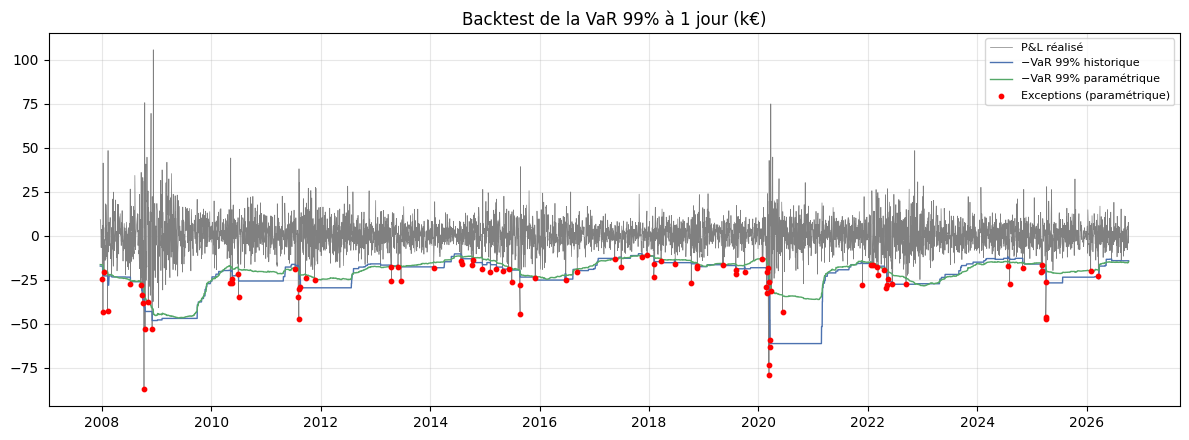

In [19]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(bt.index, bt["r"] * V / 1e3, lw=0.5, color="grey", label="P&L réalisé")
for m, c in [("Hist", "#4C72B0"), ("Param", "#55A868")]:
    col = f"{m} {A_MAX:.0%}"
    ax.plot(bt.index, -bt[col] * V / 1e3, lw=1, color=c, label=f"−VaR {A_MAX:.0%} {'historique' if m == 'Hist' else 'paramétrique'}")
exc = bt["r"] < -bt[f"Param {A_MAX:.0%}"]
ax.scatter(bt.index[exc], bt["r"][exc] * V / 1e3, color="red", s=10, zorder=3, label="Exceptions (paramétrique)")
ax.set_title(f"Backtest de la VaR {A_MAX:.0%} à 1 jour (k€)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/06_backtest.png", dpi=150); plt.show()

## 6. Module de stress tests
Toutes les pertes sont comparées à la **VaR 99 % et à l'ES 99 % historiques** (1 jour et 10 jours).

In [20]:
REF_VAR = {h: results[(h, "Historique", A_MAX)][0] for h in HORIZONS}
REF_ES = {h: results[(h, "Historique", A_MAX)][1] for h in HORIZONS}
stress_rows = []

def add_stress(name, loss_eur, detail=""):
    row = {"Scénario": name, "Perte €": loss_eur, "Perte %": loss_eur / V}
    for h in HORIZONS:
        row[f"÷ VaR {A_MAX:.0%} {h}j"] = loss_eur / REF_VAR[h]
        row[f"÷ ES {A_MAX:.0%} {h}j"] = loss_eur / REF_ES[h]
    row["Commentaire"] = detail
    stress_rows.append(row)

### 6.1 Épisodes historiques
Le moteur rejoue la crise sur les **poids actuels** (achat-conservation sur la fenêtre). Si un actif n'existait pas encore, on utilise un **proxy** (par défaut SPY) et on le signale.

In [21]:
EPISODES = {
    "1": ("Crise financière 2008 (Lehman)", "2008-09-01", "2009-03-09"),
    "2": ("Krach Covid (mars 2020)", "2020-02-19", "2020-03-23"),
    "3": ("Choc de taux 2022", "2022-01-03", "2022-10-12"),
    "4": ("Dette souveraine européenne 2011", "2011-07-01", "2011-10-03"),
}
print("Épisodes disponibles :")
for k, (n_, s_, e_) in EPISODES.items():
    print(f"  {k}. {n_} : {s_} → {e_}")
chosen = ask("Épisodes à rejouer (numéros séparés par des espaces)", "1 2 3", lambda s: s.split(),
             lambda c: None if c and all(x in EPISODES for x in c) else f"choisir parmi {list(EPISODES)}.")
custom = ask("Fenêtre personnalisée en plus ? 'AAAA-MM-JJ AAAA-MM-JJ' ou 'non'", "non",
             lambda s: None if s.lower() == "non" else tuple(pd.Timestamp(x).date().isoformat() for x in s.split()),
             lambda c: None if c is None or (len(c) == 2 and c[0] < c[1]) else "deux dates, début avant fin.")
PROXY = ask("Proxy pour un actif sans historique sur la fenêtre", "SPY" if "SPY" in TICKERS else TICKERS[0],
            lambda s: s.strip().upper(), lambda p: None if p in TICKERS else "le proxy doit faire partie du portefeuille.")

def replay(start, end):
    win = prices_full.loc[start:end]
    r = win.iloc[-1] / win.iloc[0] - 1
    proxied = [t for t in TICKERS if pd.isna(r[t])]
    for t in proxied:
        r[t] = r[PROXY]
    return r.fillna(0), proxied

episodes = [EPISODES[k] for k in chosen] + ([("Fenêtre personnalisée", *custom)] if custom else [])
hist_detail = {}
for name, s_, e_ in episodes:
    r, proxied = replay(s_, e_)
    loss_by_asset = -V * w * r
    hist_detail[name] = pd.DataFrame({"Rendement": r, "Perte €": loss_by_asset})
    worst = loss_by_asset.idxmax()
    note = f"actif le plus pénalisant : {worst} ({r[worst]:+.1%})" + (f" ; proxy {PROXY} pour {proxied}" if proxied else "")
    add_stress(f"Historique : {name}", loss_by_asset.sum(), note)
    print(f"\n{name} ({s_} → {e_}) : perte {eur(loss_by_asset.sum())} ({loss_by_asset.sum() / V:.1%}) — {note}")
    print(hist_detail[name].assign(Rendement=lambda d: d["Rendement"].map("{:+.1%}".format),
                                   **{"Perte €": lambda d: d["Perte €"].map(eur)}).to_string())

Épisodes disponibles :
  1. Crise financière 2008 (Lehman) : 2008-09-01 → 2009-03-09
  2. Krach Covid (mars 2020) : 2020-02-19 → 2020-03-23
  3. Choc de taux 2022 : 2022-01-03 → 2022-10-12
  4. Dette souveraine européenne 2011 : 2011-07-01 → 2011-10-03
Épisodes à rejouer (numéros séparés par des espaces) [défaut : 1 2 3] : 2
Fenêtre personnalisée en plus ? 'AAAA-MM-JJ AAAA-MM-JJ' ou 'non' [défaut : non] : non
Proxy pour un actif sans historique sur la fenêtre [défaut : SPY] : SPY

Krach Covid (mars 2020) (2020-02-19 → 2020-03-23) : perte €230,064 (23.0%) — actif le plus pénalisant : SPY (-33.1%)
       Rendement   Perte €
Ticker                    
SPY       -33.1%   €66,182
AAPL      -30.0%   €30,014
TLT       +15.3%  -€22,970
GLD        -2.7%    €2,706
VNQ       -41.0%   €40,989
MC.PA     -25.7%   €51,378
TTE.PA    -41.2%   €61,765


### 6.2 Chocs hypothétiques
Deux variantes : (a) un **choc en % saisi pour chaque actif** ; (b) un **choc de marché transmis par les bêtas** (βᵢ = Cov(rᵢ, r_marché) / Var(r_marché), estimés sur la fenêtre d'estimation).

In [22]:
DEFAULT_SHOCKS = {"SPY": -15, "AAPL": -25, "TLT": -5, "GLD": 5, "VNQ": -20, "MC.PA": -20, "TTE.PA": -15}
dflt = " ".join(str(DEFAULT_SHOCKS.get(t, -15)) for t in TICKERS)
shocks = ask(f"(a) Chocs en % par actif dans l'ordre {TICKERS}", dflt,
             lambda s: np.array(parse_list(s.replace(",", "."))) / 100,
             lambda x: None if len(x) == N and all(-1 <= v <= 1 for v in x) else f"{N} chocs entre -100 et +100.")
loss_a = -V * w * shocks
print(pd.DataFrame({"Choc": [f"{x:+.0%}" for x in shocks], "Perte €": [eur(x) for x in loss_a]}, index=TICKERS).to_string())
add_stress("Hypothétique : chocs par actif", loss_a.sum(), f"actif le plus pénalisant : {TICKERS[int(np.argmax(loss_a))]}")

MARKET = ask("(b) Actif représentant le marché", "SPY" if "SPY" in TICKERS else TICKERS[0],
             lambda s: s.strip().upper(), lambda p: None if p in TICKERS else "doit faire partie du portefeuille.")
MKT_SHOCK = ask("(b) Choc de marché en %", -20, lambda s: float(s.replace(",", ".")) / 100,
                lambda x: None if -1 <= x < 0 else "choc négatif entre -100 et 0.")
betas = est.cov()[MARKET] / est[MARKET].var()
shock_b = (betas * MKT_SHOCK).clip(lower=-1)
loss_b = -V * w * shock_b.values
print(pd.DataFrame({"Bêta": betas.round(2), "Choc implicite": shock_b.map("{:+.1%}".format),
                    "Perte €": [eur(x) for x in loss_b]}).to_string())
add_stress(f"Hypothétique : marché {MKT_SHOCK:+.0%} via bêtas", loss_b.sum(),
           f"actif le plus pénalisant : {TICKERS[int(np.argmax(loss_b))]}")

(a) Chocs en % par actif dans l'ordre ['SPY', 'AAPL', 'TLT', 'GLD', 'VNQ', 'MC.PA', 'TTE.PA'] [défaut : -15 -25 -5 5 -20 -20 -15] : -15 -25 -5 5 -20 -20 -15
        Choc  Perte €
SPY     -15%  €30,000
AAPL    -25%  €25,000
TLT      -5%   €7,500
GLD      +5%  -€5,000
VNQ     -20%  €20,000
MC.PA   -20%  €40,000
TTE.PA  -15%  €22,500
(b) Actif représentant le marché [défaut : SPY] : SPY
(b) Choc de marché en % [défaut : -20] : -20
        Bêta Choc implicite  Perte €
Ticker                              
SPY     1.00         -20.0%  €40,000
AAPL    1.07         -21.3%  €21,305
TLT     0.25          -5.1%   €7,592
GLD     0.39          -7.9%   €7,886
VNQ     0.61         -12.2%  €12,225
MC.PA   0.27          -5.4%  €10,847
TTE.PA  0.05          -1.0%   €1,434


### 6.3 Stress de corrélation
Toutes les corrélations deux à deux sont fixées à ρ* (entre 0,8 et 1), les volatilités restent inchangées. Σ* = D·C*·D.

In [23]:
RHO = ask("ρ* (entre 0.8 et 1)", 0.9, lambda s: float(s.replace(",", ".")),
          lambda r: None if 0.8 <= r <= 1 else "ρ* doit être compris entre 0,8 et 1.")
sd = np.sqrt(np.diag(cov))

def stressed_cov(rho):
    C = np.full((N, N), rho)
    np.fill_diagonal(C, 1)
    return np.outer(sd, sd) * C

def risk_under(C, label):
    s = np.sqrt(w @ C @ w)
    out = {"Scénario": label, "Vol. annuelle": s * np.sqrt(TRADING_DAYS)}
    for h in HORIZONS:
        v_, e_ = var_es_normal(mu_p * h, s * np.sqrt(h), A_MAX, V)
        vm, em = var_es_empirical(simulate_pnl(mu_vec, C, h), A_MAX)
        out.update({f"VaR {A_MAX:.0%} {h}j param.": v_, f"ES {A_MAX:.0%} {h}j param.": e_,
                    f"VaR {A_MAX:.0%} {h}j MC": vm, f"ES {A_MAX:.0%} {h}j MC": em})
    return out

C_rho = stressed_cov(RHO)
corr_tab = pd.DataFrame([risk_under(cov, "Base (corrélations estimées)"),
                         risk_under(C_rho, f"Corrélations = {RHO}"),
                         risk_under(stressed_cov(1.0), "Corrélations = 1 (aucune diversification)")]).set_index("Scénario")
print(corr_tab.apply(lambda c: c.map("{:.1%}".format) if c.name == "Vol. annuelle" else c.map(eur)).to_string())
base_var1 = corr_tab.iloc[0][f"VaR {A_MAX:.0%} {HORIZONS[0]}j param."]
add_stress(f"Corrélation ρ* = {RHO} (VaR {A_MAX:.0%} {HORIZONS[0]}j)", corr_tab.iloc[1][f"VaR {A_MAX:.0%} {HORIZONS[0]}j param."],
           f"vol. {corr_tab.iloc[0]['Vol. annuelle']:.1%} → {corr_tab.iloc[1]['Vol. annuelle']:.1%}")

ρ* (entre 0.8 et 1) [défaut : 0.9] : 0.9
                                          Vol. annuelle VaR 99% 1j param. ES 99% 1j param. VaR 99% 1j MC ES 99% 1j MC
Scénario                                                                                                             
Base (corrélations estimées)                      11.8%           €16,954          €19,478       €17,370      €20,125
Corrélations = 0.9                                20.3%           €29,435          €33,777       €29,999      €34,765
Corrélations = 1 (aucune diversification)         21.2%           €30,757          €35,291       €31,492      €36,404


### 6.4 Stress de volatilité
Toutes les volatilités sont multipliées par k (entre 1,5 et 3) : Σ* = k²·Σ. VaR et ES paramétriques sont linéaires en σ.

In [24]:
K = ask("k (entre 1.5 et 3)", 2, lambda s: float(s.replace(",", ".")),
        lambda k: None if 1.5 <= k <= 3 else "k doit être compris entre 1,5 et 3.")
vol_tab = pd.DataFrame([risk_under(cov, "Base"), risk_under(cov * K ** 2, f"Volatilités × {K}")]).set_index("Scénario")
print(vol_tab.apply(lambda c: c.map("{:.1%}".format) if c.name == "Vol. annuelle" else c.map(eur)).to_string())
add_stress(f"Volatilité × {K} (VaR {A_MAX:.0%} {HORIZONS[0]}j)", vol_tab.iloc[1][f"VaR {A_MAX:.0%} {HORIZONS[0]}j param."],
           "régime de forte volatilité type mars 2020")

k (entre 1.5 et 3) [défaut : 2] : 2
                  Vol. annuelle VaR 99% 1j param. ES 99% 1j param. VaR 99% 1j MC ES 99% 1j MC
Scénario                                                                                     
Base                      11.8%           €16,954          €19,478       €17,370      €20,125
Volatilités × 2.0         23.6%           €34,279          €39,326       €35,110      €40,620


### 6.5 Reverse stress test
On part d'une **perte inacceptable** et on cherche les chocs qui la provoquent :
1. choc uniforme sur tous les actifs ;
2. choc nécessaire sur **un seul actif** (−L / wᵢ) ;
3. **scénario le plus plausible** sous la loi normale : x* = −L·Σw / (wᵀΣw) (le choc qui atteint la perte avec la plus petite distance de Mahalanobis), avec le nombre d'écarts-types correspondant ;
4. multiple de chaque crise historique nécessaire pour atteindre la limite.

In [25]:
L = ask("Limite de perte en % de la valeur", 20, lambda s: float(s.replace(",", ".")) / 100,
        lambda x: None if 0 < x < 1 else "limite entre 0 et 100 %.")
print(f"Limite : {L:.0%} = {eur(L * V)}\n")
print(f"1) Choc uniforme nécessaire : {-L:.1%} sur chaque actif.\n")

single = pd.DataFrame({"Poids": w, "Choc nécessaire": -L / w}, index=TICKERS)
single["Réaliste ?"] = np.where(single["Choc nécessaire"] >= -1, "possible", "impossible (> −100 %)")
print("2) Choc sur un seul actif :")
print(single.assign(Poids=single["Poids"].map("{:.0%}".format),
                    **{"Choc nécessaire": single["Choc nécessaire"].map("{:+.0%}".format)}).to_string())

x_star_1 = -L * (cov @ w) / (w @ cov @ w)     # même direction quel que soit l'horizon
print("\n3) Scénario le plus plausible (chocs par actif) :")
print(pd.Series(x_star_1, index=TICKERS).map("{:+.1%}".format).to_string())
for h in HORIZONS:
    n_sd = L / np.sqrt(h * (w @ cov @ w))
    print(f"   sur {h} jour(s) : la perte représente {n_sd:.1f} écarts-types (probabilité normale ≈ {norm.sf(n_sd):.1e})")
add_stress(f"Reverse : perte limite {L:.0%}", L * V,
           f"choc le plus plausible : {TICKERS[int(np.argmin(x_star_1))]} {x_star_1.min():+.0%}, uniforme {-L:.0%}")

print("\n4) Multiple de chaque crise historique nécessaire :")
for name, d in hist_detail.items():
    loss_pct = d["Perte €"].sum() / V
    print(f"   {name} : × {L / loss_pct:.2f}" if loss_pct > 0 else f"   {name} : pas de perte")

Limite de perte en % de la valeur [défaut : 20] : 20
Limite : 20% = €200,000

1) Choc uniforme nécessaire : -20.0% sur chaque actif.

2) Choc sur un seul actif :
       Poids Choc nécessaire             Réaliste ?
SPY      20%           -100%               possible
AAPL     10%           -200%  impossible (> −100 %)
TLT      15%           -133%  impossible (> −100 %)
GLD      10%           -200%  impossible (> −100 %)
VNQ      10%           -200%  impossible (> −100 %)
MC.PA    20%           -100%               possible
TTE.PA   15%           -133%  impossible (> −100 %)

3) Scénario le plus plausible (chocs par actif) :
SPY       -19.6%
AAPL      -28.3%
TLT       -10.4%
GLD       -15.7%
VNQ       -18.6%
MC.PA     -32.0%
TTE.PA    -12.3%
   sur 1 jour(s) : la perte représente 26.9 écarts-types (probabilité normale ≈ 3.6e-159)

4) Multiple de chaque crise historique nécessaire :
   Krach Covid (mars 2020) : × 0.87


### 6.6 Tableau comparatif : stress vs VaR et ES
Ratio > 1 → le scénario dépasse ce que la VaR/ES « voit ». Pour les stress de corrélation et de volatilité, la « perte » reportée est la VaR 99 % stressée.

In [26]:
stress_tab = pd.DataFrame(stress_rows).set_index("Scénario")
stress_tab.to_csv(f"{OUT_DIR}/tab_stress.csv")
show = stress_tab.copy()
show["Perte €"] = show["Perte €"].map(eur)
show["Perte %"] = show["Perte %"].map("{:.1%}".format)
for c in show.columns:
    if c.startswith("÷"):
        show[c] = stress_tab[c].map("{:.2f}×".format)
print("Références : " + " | ".join(f"VaR {A_MAX:.0%} {h}j = {eur(REF_VAR[h])}, ES = {eur(REF_ES[h])}" for h in HORIZONS)
      + " (historiques)")
show

Références : VaR 99% 1j = €19,725, ES = €28,666 (historiques)


,Perte €,Perte %,÷ VaR 99% 1j,÷ ES 99% 1j,Commentaire
Scénario,,,,,
Historique : Krach Covid (mars 2020),"€230,064",23.0%,11.66×,8.03×,actif le plus pénalisant : SPY (-33.1%)
Hypothétique : chocs par actif,"€140,000",14.0%,7.10×,4.88×,actif le plus pénalisant : MC.PA
Hypothétique : marché -20% via bêtas,"€101,288",10.1%,5.13×,3.53×,actif le plus pénalisant : SPY
Corrélation ρ* = 0.9 (VaR 99% 1j),"€29,435",2.9%,1.49×,1.03×,vol. 11.8% → 20.3%
Volatilité × 2.0 (VaR 99% 1j),"€34,279",3.4%,1.74×,1.20×,régime de forte volatilité type mars 2020
Reverse : perte limite 20%,"€200,000",20.0%,10.14×,6.98×,"choc le plus plausible : MC.PA -32%, uniforme ..."


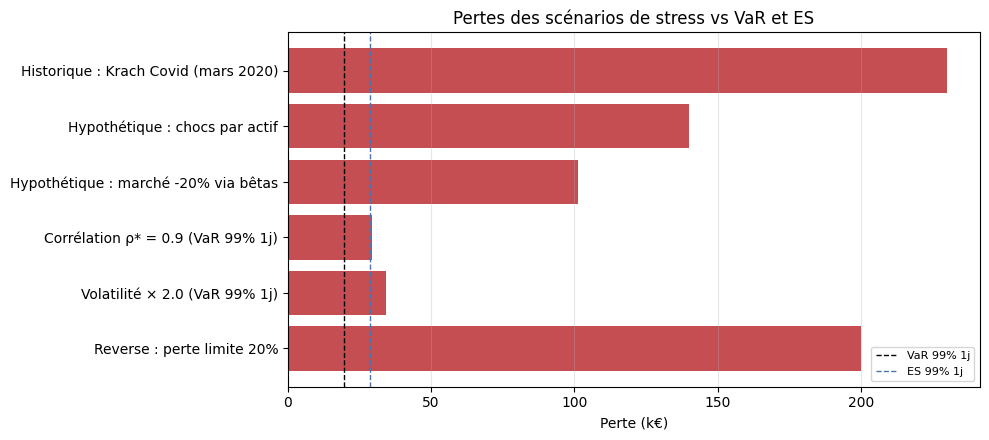

In [27]:
fig, ax = plt.subplots(figsize=(10, 0.5 * len(stress_tab) + 1.5))
ax.barh(stress_tab.index, stress_tab["Perte €"] / 1e3, color="#C44E52")
for h, ls in zip(HORIZONS, ["--", ":"]):
    ax.axvline(REF_VAR[h] / 1e3, color="k", ls=ls, lw=1, label=f"VaR {A_MAX:.0%} {h}j")
    ax.axvline(REF_ES[h] / 1e3, color="#4C72B0", ls=ls, lw=1, label=f"ES {A_MAX:.0%} {h}j")
ax.invert_yaxis(); ax.set_xlabel("Perte (k€)"); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="x")
ax.set_title("Pertes des scénarios de stress vs VaR et ES")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/07_stress_vs_var.png", dpi=150); plt.show()

## 7. Analyses complémentaires pour les questions du rapport
### 7.1 Diversification en période de crise (question 3)
Corrélation moyenne entre actifs et ratio de diversification (moyenne pondérée des volatilités ÷ volatilité du portefeuille) selon la période.

In [28]:
def div_stats(r):
    c = r.corr().values
    avg_rho = c[np.triu_indices(N, 1)].mean()
    C = r.cov().values
    sp = np.sqrt(w @ C @ w)
    return avg_rho, (w @ np.sqrt(np.diag(C))) / sp, sp * np.sqrt(TRADING_DAYS)

periods = {"Toute la période": (None, None), "Fenêtre d'estimation": (est.index[0], est.index[-1]),
           **{n_: (s_, e_) for n_, s_, e_ in episodes}}
div_rows = []
for name, (s_, e_) in periods.items():
    r = rets.loc[s_:e_]
    if len(r) > 20:
        a_, dr, v_ = div_stats(r)
        div_rows.append({"Période": name, "Jours": len(r), "Corrélation moyenne": a_,
                         "Ratio de diversification": dr, "Vol. portefeuille": v_})
div_tab = pd.DataFrame(div_rows).set_index("Période")
div_tab.to_csv(f"{OUT_DIR}/tab_diversification.csv")
div_tab.style.format({"Corrélation moyenne": "{:.2f}", "Ratio de diversification": "{:.2f}", "Vol. portefeuille": "{:.1%}"})

,Jours,Corrélation moyenne,Ratio de diversification,Vol. portefeuille
Période,,,,
Toute la période,5099,0.22,1.65,15.1%
Fenêtre d'estimation,750,0.21,1.80,11.8%
Krach Covid (mars 2020),24,0.35,1.37,53.1%


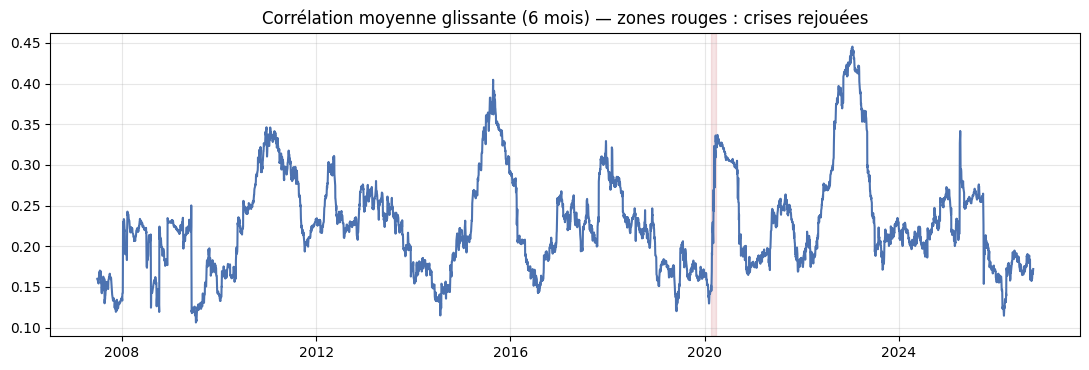

In [29]:
roll_corr = rets.rolling(126).corr()
avg_roll = roll_corr.groupby(level=0).apply(lambda m: m.values[np.triu_indices(N, 1)].mean()).dropna()
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(avg_roll.index, avg_roll, color="#4C72B0")
for _, s_, e_ in episodes:
    ax.axvspan(pd.Timestamp(s_), pd.Timestamp(e_), color="#C44E52", alpha=0.15)
ax.set_title("Corrélation moyenne glissante (6 mois) — zones rouges : crises rejouées"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/08_correlation_glissante.png", dpi=150); plt.show()

### 7.2 Effet de la concentration (question 7)
On compare le portefeuille actuel avec un portefeuille équipondéré, un portefeuille concentré à 50 % sur l'actif le plus volatil, et 100 % sur cet actif. HHI = Σwᵢ² ; nombre effectif d'actifs = 1/HHI.

In [30]:
most_vol = est.std().idxmax()
i_mv = TICKERS.index(most_vol)
w_conc = w * 0.5 / (1 - w[i_mv]) if w[i_mv] < 1 else w.copy()
w_conc[i_mv] = 0.5
w_full = np.eye(N)[i_mv]
portfolios = {"Équipondéré": np.full(N, 1 / N), "Actuel": w,
              f"50 % sur {most_vol}": w_conc, f"100 % {most_vol}": w_full}
conc_rows = []
for name, ww in portfolios.items():
    pnl = V * (est @ ww).values
    hv, he = var_es_empirical(pnl, A_MAX)
    s = np.sqrt(ww @ cov @ ww)
    conc_rows.append({"Portefeuille": name, "HHI": (ww ** 2).sum(), "Nb effectif d'actifs": 1 / (ww ** 2).sum(),
                      "Vol. annuelle": s * np.sqrt(TRADING_DAYS),
                      "Ratio de diversification": (ww @ sd) / s,
                      f"VaR {A_MAX:.0%} 1j hist.": hv, f"ES {A_MAX:.0%} 1j hist.": he})
conc_tab = pd.DataFrame(conc_rows).set_index("Portefeuille")
conc_tab.to_csv(f"{OUT_DIR}/tab_concentration.csv")
conc_tab.style.format({"HHI": "{:.3f}", "Nb effectif d'actifs": "{:.1f}", "Vol. annuelle": "{:.1%}",
                       "Ratio de diversification": "{:.2f}", f"VaR {A_MAX:.0%} 1j hist.": eur, f"ES {A_MAX:.0%} 1j hist.": eur})

,HHI,Nb effectif d'actifs,Vol. annuelle,Ratio de diversification,VaR 99% 1j hist.,ES 99% 1j hist.
Portefeuille,,,,,,
Équipondéré,0.143,7.0,11.8%,1.80,"€18,514","€29,145"
Actuel,0.155,6.5,11.8%,1.80,"€19,725","€28,666"
50 % sur MC.PA,0.295,3.4,16.8%,1.45,"€25,646","€35,051"
100 % MC.PA,1.000,1.0,29.7%,1.00,"€43,355","€55,251"


## 8. Synthèse chiffrée pour répondre aux 8 questions
Cette cellule rassemble automatiquement les chiffres clés. Les interprétations sont à rédiger dans le rapport PDF.

In [31]:
h1 = HORIZONS[0]
hv, pv_, mv = (results[(h1, m, A_MAX)][0] for m in ["Historique", "Paramétrique", "Monte Carlo"])
he, pe, me = (results[(h1, m, A_MAX)][1] for m in ["Historique", "Paramétrique", "Monte Carlo"])
s_assets = stats.drop("PORTEFEUILLE")
worst_scn = stress_tab[~stress_tab.index.str.startswith("Reverse")]["Perte €"].idxmax()
bt99 = backtest_tab[backtest_tab["Confiance"] == f"{A_MAX:.0%}"].set_index("Modèle")

print(f"""
Q1. Actif le plus volatil : {s_assets['Volatilité annuelle'].idxmax()} ({s_assets['Volatilité annuelle'].max():.1%} par an) ;
    le moins volatil : {s_assets['Volatilité annuelle'].idxmin()} ({s_assets['Volatilité annuelle'].min():.1%}). Portefeuille : {stats.loc['PORTEFEUILLE', 'Volatilité annuelle']:.1%}.

Q2. Backtest VaR {A_MAX:.0%} sur {bt99.iloc[0]['Jours testés']} jours (attendu {bt99.iloc[0]['Attendues']} exceptions) :
    Historique  : {bt99.loc['Historique', 'Exceptions']} exceptions, Kupiec p = {bt99.loc['Historique', 'p-value']} → {bt99.loc['Historique', 'Kupiec (5 %)']}, feu {bt99.loc['Historique', 'Feu Bâle']}
    Paramétrique: {bt99.loc['Paramétrique', 'Exceptions']} exceptions, Kupiec p = {bt99.loc['Paramétrique', 'p-value']} → {bt99.loc['Paramétrique', 'Kupiec (5 %)']}, feu {bt99.loc['Paramétrique', 'Feu Bâle']}

Q3. Corrélation moyenne : {div_tab['Corrélation moyenne'].iloc[0]:.2f} sur toute la période ; en crise jusqu'à {div_tab['Corrélation moyenne'].max():.2f}.
    Ratio de diversification : {div_tab['Ratio de diversification'].iloc[0]:.2f} en moyenne, {div_tab['Ratio de diversification'].min():.2f} au pire.
    Avec ρ* = {RHO} : volatilité {corr_tab.iloc[0]['Vol. annuelle']:.1%} → {corr_tab.iloc[1]['Vol. annuelle']:.1%}.

Q4. VaR {A_MAX:.0%} 1j : historique {eur(hv)} vs paramétrique {eur(pv_)} (écart {hv / pv_ - 1:+.1%}).
    Skewness du portefeuille {stats.loc['PORTEFEUILLE', 'Skewness']:.2f}, excès de kurtosis {stats.loc['PORTEFEUILLE', 'Excès de kurtosis']:.2f}
    (> 0 = queues plus épaisses que la normale → la normale sous-estime les pertes extrêmes).

Q5. VaR {A_MAX:.0%} 1j : Monte Carlo {eur(mv)} vs historique {eur(hv)} (écart {mv / hv - 1:+.1%}).
    Le Monte Carlo suppose une loi normale multivariée : il retrouve ~ le paramétrique ({eur(pv_)}), pas les queues réelles.

Q6. ES/VaR à {A_MAX:.0%} : historique {he / hv:.2f}, paramétrique {pe / pv_:.2f}, Monte Carlo {me / mv:.2f}
    (≈ 1,15 sous la normale ; plus élevé = queue plus épaisse que ce que la VaR montre).

Q7. Vol. annuelle : équipondéré {conc_tab.iloc[0]['Vol. annuelle']:.1%}, actuel {conc_tab.iloc[1]['Vol. annuelle']:.1%},
    50 % {most_vol} {conc_tab.iloc[2]['Vol. annuelle']:.1%}, 100 % {most_vol} {conc_tab.iloc[3]['Vol. annuelle']:.1%}.

Q8. Pire scénario : {worst_scn} → {eur(stress_tab.loc[worst_scn, 'Perte €'])} ({stress_tab.loc[worst_scn, 'Perte %']:.1%}),
    soit {stress_tab.loc[worst_scn].filter(like='÷ VaR').iloc[0]:.1f}× la VaR {A_MAX:.0%} {h1}j. {stress_tab.loc[worst_scn, 'Commentaire']}
""")
print("✓ Tous les tableaux (CSV) et graphiques (PNG) sont dans le dossier", OUT_DIR)


Q1. Actif le plus volatil : AAPL (32.2% par an) ;
    le moins volatil : TLT (18.8%). Portefeuille : 15.1%.

Q2. Backtest VaR 99% sur 4849 jours (attendu 48.5 exceptions) :
    Historique  : 80 exceptions, Kupiec p = 0.0 → REJETÉ, feu VERT
    Paramétrique: 93 exceptions, Kupiec p = 0.0 → REJETÉ, feu VERT

Q3. Corrélation moyenne : 0.22 sur toute la période ; en crise jusqu'à 0.35.
    Ratio de diversification : 1.65 en moyenne, 1.37 au pire.
    Avec ρ* = 0.9 : volatilité 11.8% → 20.3%.

Q4. VaR 99% 1j : historique €19,725 vs paramétrique €16,954 (écart +16.3%).
    Skewness du portefeuille -0.04, excès de kurtosis 10.76
    (> 0 = queues plus épaisses que la normale → la normale sous-estime les pertes extrêmes).

Q5. VaR 99% 1j : Monte Carlo €17,370 vs historique €19,725 (écart -11.9%).
    Le Monte Carlo suppose une loi normale multivariée : il retrouve ~ le paramétrique (€16,954), pas les queues réelles.

Q6. ES/VaR à 99% : historique 1.45, paramétrique 1.15, Monte Carlo 1.16
    